# Plotting with Matplotlib

Matplotlib is the plotting library used in this repository. This example shows how to use $\LaTeX$ for text rendering, how to select the font, and sizing the image so font sizes are correct. Most of the information was learned from the excellent guide [Plot publication-quality figures with matplotlib and LaTeX](https://jwalton.info/Embed-Publication-Matplotlib-Latex/) by Jack Walton.

In [1]:
import matplotlib.pyplot as plt

Matplotlib already produces good looking plots and supports all the functionality necessary to customize the content and layout to best communicate the information contained within. To integrate the plot into an existing document there are a few straightforward properties to modify.

1) Font
2) Size
3) Colors

First, find the font used in your document and configure Matplotlib to use that font and also tell it to use LaTeX to render the text. This does require having a $\LaTeX$ processor setup and available in the same environment as the Python code is running.

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Palatino"
})

Using the $\LaTeX$ runtime to process the texts gives us consistent handling of the font and text, as well as enabling the use of mathematical symbols and equations.

This code creates a basic plot which shows the use of literal strings to pass math environments to the axis labels.

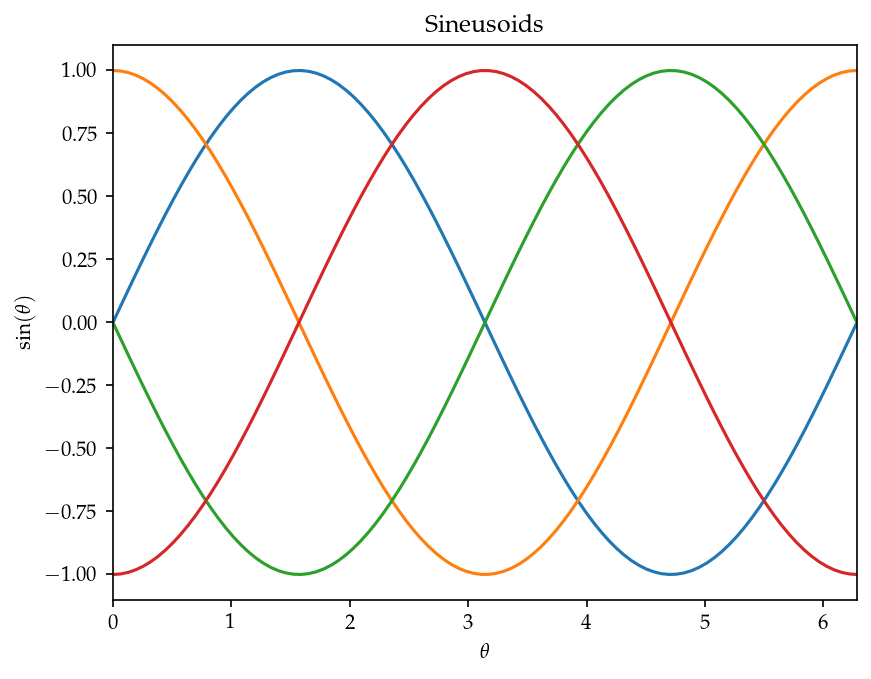

In [3]:
# Initialise figure instance
fig, ax = plt.subplots(1, 1, dpi=150)

# Create the plot
# Numpy used for convenient math operations
import numpy as np

x = np.linspace(0, 2*np.pi, 100)
for c in [0, 0.5, 1, 1.5]:
    ax.plot(x, np.sin(x+c*np.pi))

ax.set_xlim(0, 2 * np.pi)
ax.set_title("Sineusoids")

# LaTeX math can be entered using literal strings
# https://docs.python.org/3/reference/lexical_analysis.html#string-and-bytes-literals
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$\sin (\theta)$')

plt.show()

This plot has used the default fontsizes for the title and labels. It's simple to change those on a per-plot basis but the philosophy of $\LaTeX$ is to separate formatting from content so let's embrace that.  Matplotlib includes a default stylesheet which defines many properties including the fontsizes for titles and lables. Lets customize some of those now.

In [4]:
plt.rcParams.update({
    "axes.labelsize": 11,
    "font.size": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9
})

The stylesheet can customize other properties of the plot including markersize, default colors of the lines, and colors of the axis.

My preference was to use a slightly off-black (Hex 191919) for elements.

In [5]:
from cycler import cycler

plt.rcParams.update({
    "lines.markersize": 3,
    "axes.prop_cycle" : cycler('color', ['#B74331', '#216072', '#B77531', '#248742']),
    "axes.edgecolor" : '#191919',
    "text.color" : '#191919',
    "axes.labelcolor" : '#191919',
    "xtick.color" : '#191919',
    "ytick.color" : '#191919'
})

Lets see how that's changed the plot. It's subtle, but when the fonts, fontsizes, and colors are consistent with the text it does make a big difference.

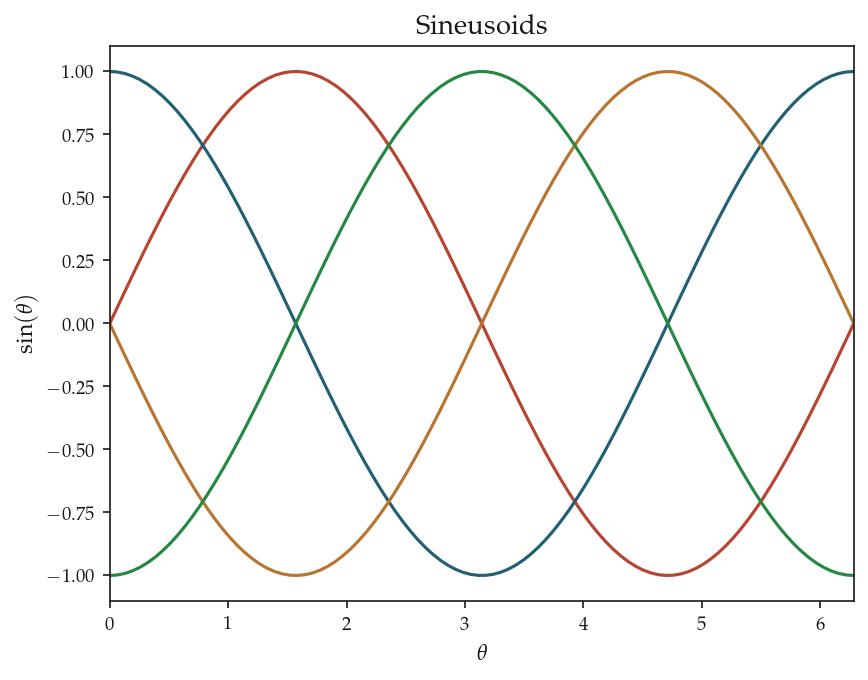

In [16]:
fig, ax = plt.subplots(1, 1, dpi=150)

x = np.linspace(0, 2*np.pi, 100)
for c in [0, 0.5, 1, 1.5]:
    ax.plot(x, np.sin(x+c*np.pi))

ax.set_xlim(0, 2 * np.pi)
ax.set_title("Sineusoids")

ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$\sin (\theta)$')

plt.show()

Defining these properties will make the formatting consistent for all plots in the current Python script. However it's likely that you'll want to create plots in more than one script. It'd be useful to separate the styles into a separate stylesheet and just load it in each script. This way formatting has one source of definition and won't become inconsistent. All the previous styles are contained in `thesis.mplstyle` and can be loaded like this:

In [18]:
plt.style.use("./thesis.mplstyle")

Having set the formatting, now the image needs to be generated in a format which will preserve the formatting and quality when loaded. Matplotlib can write many filetypes, I used PDF as it is a vector filetype and easy to include in $\LaTeX$ figures. As a vector it does not lose quality when scaled in size, however we've just put the work in to set the fontsizes and those will get distorted unless the figure is created with an awareness of it's final size in the written document.

$\LaTeX$ has the commands `\the\textwidth` which can be inserted into your document. The width of the current layout area will be printed in the document. Use `\the\columnwidth` if the layout has multiple columns. For the example document the text is 360.0 points wide. Jack wrote a function which calculates the width and height for a plot from the width of the text area, what fraction of that width the figure will be, and how many subplots are being created.

In [19]:
def set_size(width="thesis", fraction=1, subplots=(1, 1)):
    """Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    ----------
    width: float or string, optional
            Document width in points, or string of predined document type
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Code from https://jwalton.info/Embed-Publication-Matplotlib-Latex/
    if width == 'thesis':
        # Value found by inserting "\showthe\textwidth" into the TeX document
        width_pt = 360
    else:
        width_pt = width

    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    # https://disq.us/p/2940ij3
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)

This function is used to set the `figsize` property of a [figure](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.figure.html#matplotlib.pyplot.figure). In this case, the full width of the document's text area.

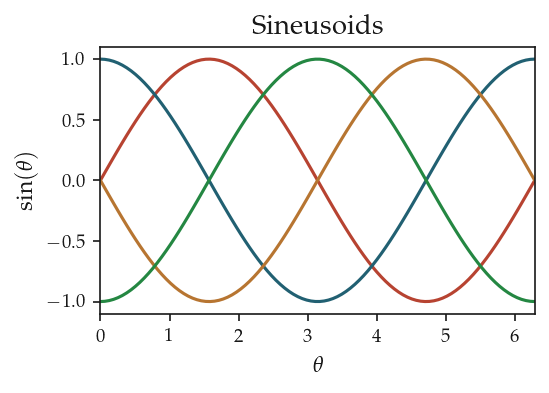

In [25]:
fig, ax = plt.subplots(1, 1, figsize=set_size(width=360, fraction=0.75), dpi=150)

x = np.linspace(0, 2*np.pi, 100)
for c in [0, 0.5, 1, 1.5]:
    ax.plot(x, np.sin(x+c*np.pi))

ax.set_xlim(0, 2 * np.pi)
ax.set_title("Sineusoids")

ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$\sin (\theta)$')

plt.show()

This figure can now be saved as a PDF. Setting the bounding box to 'tight' removed extra margins which would scale the image.

In [26]:
fig.savefig('example.pdf', format='pdf', bbox_inches='tight')

This PDF can now be included in the document using standard commands.

```latex
\begin{figure}[h]
	\centering
	\includegraphics[width=1\textwidth]{example.pdf}
	\caption{An example plot with matching font scaling}
	\label{fig:example}
\end{figure}
```

Open [document.pdf](document.pdf) to see the result.